uploading datasets

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Smartphone_Usage_Productivity_Dataset_50000.csv to Smartphone_Usage_Productivity_Dataset_50000.csv


installing liberaries

In [ ]:
!pip install xgboost shap scikit-learn pandas numpy matplotlib seaborn

verifing everything woorks

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import sklearn
print("all liberaries is loaded")

all liberaries is loaded


loading dataset into the data frame

In [ ]:
df=pd.read_csv('Smartphone_Usage_Productivity_Dataset_50000.csv')

printinf total rows and columns

In [ ]:
print(df.shape)

(50000, 13)


printing first five rows of the dataset

In [ ]:
print(df.head())

  User_ID  Age  Gender      Occupation Device_Type  Daily_Phone_Hours  \
0      U1   58    Male    Professional     Android                1.3   
1      U2   25    Male    Professional     Android                1.2   
2      U3   19    Male         Student         iOS                5.3   
3      U4   35  Female  Business Owner         iOS                5.8   
4      U5   33    Male      Freelancer     Android                7.9   

   Social_Media_Hours  Work_Productivity_Score  Sleep_Hours  Stress_Level  \
0                 6.7                        6          8.8             4   
1                 1.5                        5          6.4             1   
2                 5.7                        5          9.0             4   
3                 2.5                        2          5.7             3   
4                 1.3                        4          5.7             3   

   App_Usage_Count  Caffeine_Intake_Cups  Weekend_Screen_Time_Hours  
0               42          

checking basic statisticss from dataset

In [ ]:
print(df.describe())

                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000            8.000000   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             50000.000000  50000.000000  50000.000000      50000.00000   
mean                  5.503760      6.497744      5.504500         32.43898   
std                   2.874806      1.449551      2.871095         16.12151   
min                   1.000000      4.000000      1.000000          5.00000   
25%                   3.000000      5.200000  

mising value checking

In [ ]:
print(df.isnull().sum())

User_ID                      0
Age                          0
Gender                       0
Occupation                   0
Device_Type                  0
Daily_Phone_Hours            0
Social_Media_Hours           0
Work_Productivity_Score      0
Sleep_Hours                  0
Stress_Level                 0
App_Usage_Count              0
Caffeine_Intake_Cups         0
Weekend_Screen_Time_Hours    0
dtype: int64


datatype of each cell

In [ ]:
print(df.dtypes)

User_ID                       object
Age                            int64
Gender                        object
Occupation                    object
Device_Type                   object
Daily_Phone_Hours            float64
Social_Media_Hours           float64
Work_Productivity_Score        int64
Sleep_Hours                  float64
Stress_Level                   int64
App_Usage_Count                int64
Caffeine_Intake_Cups           int64
Weekend_Screen_Time_Hours    float64
dtype: object


creating addiction label based on research backed thresholds

In [ ]:
def label_addiction(row):
  score = 0
  if row['Daily_Phone_Hours'] > 6:
    score += 1
  if row['Social_Media_Hours'] > 3:
    score += 1
  if row['Sleep_Hours'] > 6:
    score += 1
  if row['Stress_Level'] >= 7:
    score += 1
  if row['Work_Productivity_Score'] <= 3:
     score += 1
  if row['Weekend_Screen_Time_Hours'] > 10:
    score += 1

  return 1 if score >= 3 else 0
df['Is_Addicted'] = df.apply(label_addiction, axis=1)
print(df['Is_Addicted'].value_counts())

Is_Addicted
1    30255
0    19745
Name: count, dtype: int64


saving preprocessed dataset with Is_Addicted collum

In [ ]:
df.to_csv('preprocessed_dataset.csv', index=False)
print("File is Saved")

File is Saved


downloading datadet

In [ ]:
from google.colab import files
files.download('preprocessed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

creating new columns from existing daata which helpsin better result and detection
column 1 screen to sleep ratio

daily phone hours / sleep hour

column 2 social media ratio

 daily phone hours /socia; ,media hours

 column 3productivity stress gap

work productivity screen  - stress hour

 column 4 totlal screen time

weekend screen time hour + daily phone hours

In [ ]:
df['Screen_to_Sleep_Ratio']= df['Daily_Phone_Hours'] / df['Sleep_Hours']
df['Social_Media_Ratio']= df['Daily_Phone_Hours'] / df['Social_Media_Hours']
df['Productivity_Stress_Gap']= df['Work_Productivity_Score'] - df['Stress_Level']
df['Total_Screen_Time']= df['Weekend_Screen_Time_Hours'] + df['Daily_Phone_Hours']
print("New features created")



New features created


In [ ]:
print(df[['Screen_to_Sleep_Ratio','Social_Media_Ratio','Productivity_Stress_Gap','Total_Screen_Time',]].head())


   Screen_to_Sleep_Ratio  Social_Media_Ratio  Productivity_Stress_Gap  \
0               0.147727            0.194030                        2   
1               0.187500            0.800000                        4   
2               0.588889            0.929825                        1   
3               1.017544            2.320000                       -1   
4               1.385965            6.076923                        1   

   Total_Screen_Time  
0               10.0  
1                6.3  
2               11.6  
3               18.6  
4               17.8  


In [ ]:
print("Total column :" ,len(df.columns))
print(df.columns.tolist())

Total column : 18
['User_ID', 'Age', 'Gender', 'Occupation', 'Device_Type', 'Daily_Phone_Hours', 'Social_Media_Hours', 'Work_Productivity_Score', 'Sleep_Hours', 'Stress_Level', 'App_Usage_Count', 'Caffeine_Intake_Cups', 'Weekend_Screen_Time_Hours', 'Is_Addicted', 'Screen_to_Sleep_Ratio', 'Social_Media_Ratio', 'Productivity_Stress_Gap', 'Total_Screen_Time']


downlloadng updated version of preprcessed data

In [ ]:
df.to_csv('preprocessed_dataset.csv',index= False)
print ("file is updated")

file is updated


In [ ]:
files.download('preprocessed_dataset.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

preparing data for the model
importing tools train_test_split for spliting the data for train and testing
label encoder for labeling the required data values


creating a copy of dataset to kkeep data safe for future use
creating a new dataframe wihout user id  column

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
df_model = df.drop(['User_ID'], axis=1)


In [ ]:
le=LabelEncoder()

In [ ]:
df_model['Gender'] = le.fit_transform(df_model['Gender'])
df_model['Occupation'] = le.fit_transform(df_model['Occupation'])
df_model['Device_Type'] = le.fit_transform(df_model['Device_Type'])

X = df_model.drop('Is_Addicted', axis=1)
y = df_model['Is_Addicted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready for training ✅")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data ready for training ✅
Training samples: 40000
Testing samples: 10000


PHASE 4 - MODEL TRAINING
 Training 3 models at once and comparing them

In [ ]:


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# Define all 3 models
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting"   : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and test each model one by one
trained_models = {}
for name, model in models.items():
    # Train the model on 40,000 rows
    model.fit(X_train, y_train)
    # Test the model on 10,000 unseen rows
    preds = model.predict(X_test)
    # Calculate accuracy
    acc = accuracy_score(y_test, preds)
    # Save trained model
    trained_models[name] = model
    print(f"\n{'='*45}")
    print(f"  {name}  |  Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, preds))


  Logistic Regression  |  Accuracy: 83.97%
              precision    recall  f1-score   support

           0       0.80      0.78      0.79      3892
           1       0.86      0.88      0.87      6108

    accuracy                           0.84     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.84      0.84      0.84     10000


  Random Forest  |  Accuracy: 99.99%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3892
           1       1.00      1.00      1.00      6108

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


  Gradient Boosting  |  Accuracy: 100.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3892
           1       1.00      1.00      1.00      6108

    accuracy                           1.00     10000
   

In [ ]:
# =============================================
# FIXING OVERFITTING
# Better label engineering with weighted scoring
# =============================================

def label_addiction_improved(row):
    score = 0

    # HIGH WEIGHT signals (2 points each)
    # These are strongest addiction indicators
    if row['Daily_Phone_Hours'] > 7:
        score += 2
    elif row['Daily_Phone_Hours'] > 5:
        score += 1

    if row['Sleep_Hours'] < 5:
        score += 2
    elif row['Sleep_Hours'] < 6.5:
        score += 1

    if row['Stress_Level'] >= 8:
        score += 2
    elif row['Stress_Level'] >= 6:
        score += 1

    # LOW WEIGHT signals (1 point each)
    # Supporting indicators
    if row['Social_Media_Hours'] > 4:
        score += 1
    if row['Work_Productivity_Score'] <= 2:
        score += 1
    if row['Weekend_Screen_Time_Hours'] > 11:
        score += 1
    if row['Screen_to_Sleep_Ratio'] > 1.5:
        score += 1
    if row['Social_Media_Ratio'] > 0.6:
        score += 1

    # Need score of 5 or more to be addicted
    return 1 if score >= 5 else 0

# Apply improved labels
df['Is_Addicted'] = df.apply(label_addiction_improved, axis=1)

# Check new distribution
print("Addiction distribution:")
print(df['Is_Addicted'].value_counts())
print("\nAddiction rate:", round(df['Is_Addicted'].mean() * 100, 2), "%")


Addiction distribution:
Is_Addicted
1    25004
0    24996
Name: count, dtype: int64

Addiction rate: 50.01 %


In [ ]:
# =============================================
# RETRAIN - Prepare data with improved labels
# =============================================

# Encode text columns to numbers
le = LabelEncoder()
df_model = df.drop(['User_ID'], axis=1)
df_model['Gender'] = le.fit_transform(df_model['Gender'])
df_model['Occupation'] = le.fit_transform(df_model['Occupation'])
df_model['Device_Type'] = le.fit_transform(df_model['Device_Type'])

# Separate features and target
X = df_model.drop('Is_Addicted', axis=1)
y = df_model['Is_Addicted']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data ready for retraining ✅")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Data ready for retraining ✅
Training samples: 40000
Testing samples: 10000


In [ ]:
# =============================================
# TRAINING ALL 3 MODELS WITH IMPROVED LABELS
# =============================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# MODEL 1 - Logistic Regression
# Simple baseline model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# MODEL 2 - Random Forest
# Multiple decision trees combined
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

# MODEL 3 - Gradient Boosting
# Trees built one after another to fix errors
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)

# Print all results
print("=" * 45)
print(f"Logistic Regression  | Accuracy: {lr_acc*100:.2f}%")
print("=" * 45)
print(f"Random Forest        | Accuracy: {rf_acc*100:.2f}%")
print("=" * 45)
print(f"Gradient Boosting    | Accuracy: {gb_acc*100:.2f}%")
print("=" * 45)

Logistic Regression  | Accuracy: 88.82%
Random Forest        | Accuracy: 99.39%
Gradient Boosting    | Accuracy: 99.48%


 PHASE 5 - SHAP EXPLAINABILITY
 Understanding WHY model makes predictions

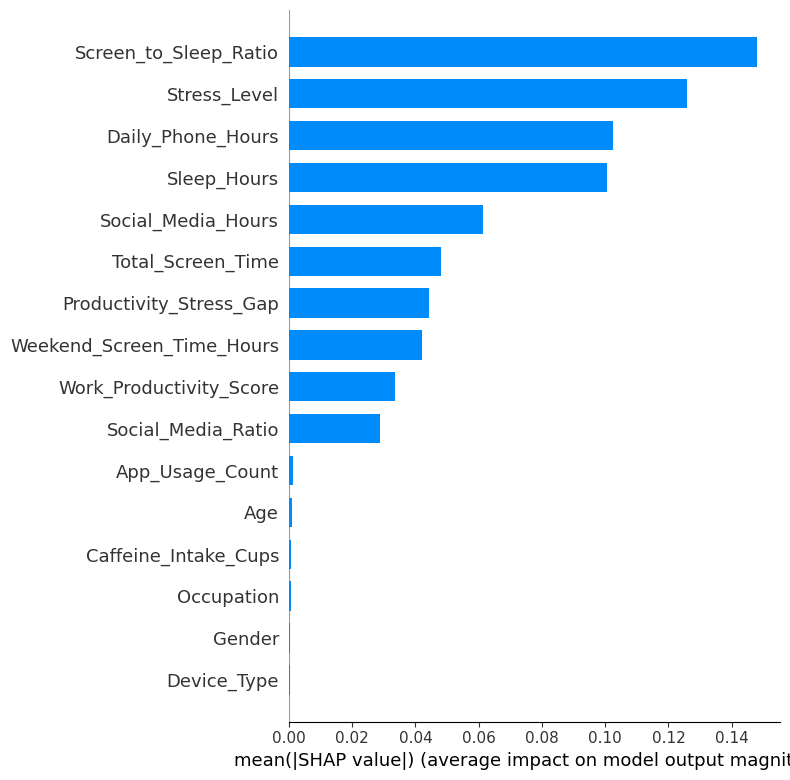

In [ ]:

import shap
import matplotlib.pyplot as plt

# Use Random Forest model for SHAP
explainer = shap.TreeExplainer(rf_model)

# Calculate SHAP values on test data
# Using sample of 1000 rows to speed up
shap_values = explainer.shap_values(X_test[:1000])

# Plot - Which features matter most for prediction
shap.summary_plot(shap_values[:,:,1], X_test[:1000], plot_type="bar")

In [ ]:
 SHAP SUMMARY PLOT
 Shows HOW each feature affects prediction
 Red = High value, Blue = Low value

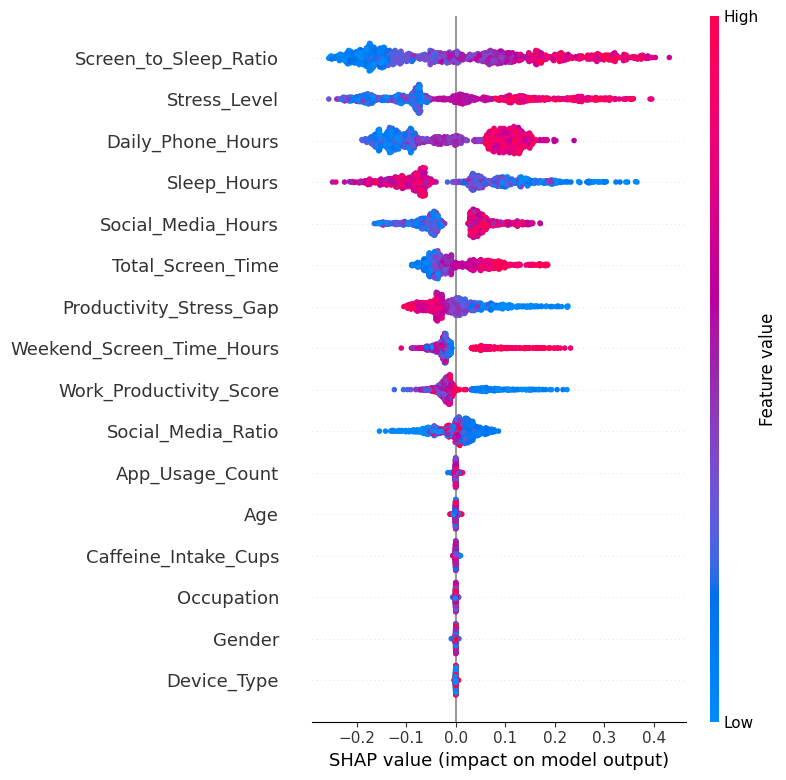

In [ ]:
shap.summary_plot(shap_values[:,:,1], X_test[:1000])

In [ ]:
CONFUSION MATRIX
 Shows how many predictions were correct

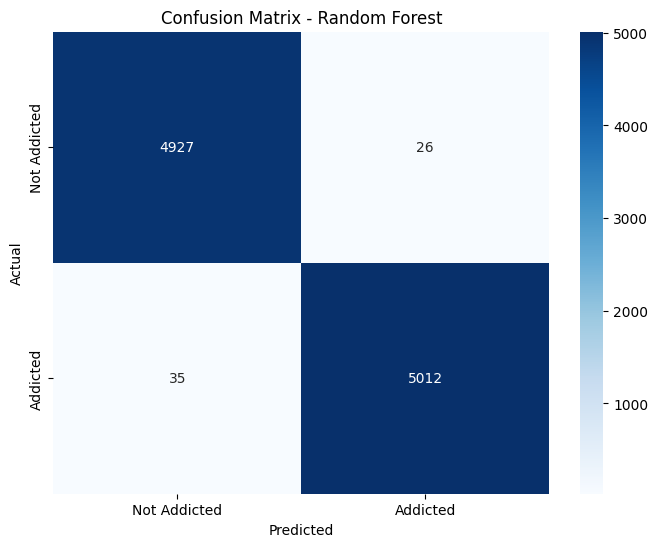

In [ ]:


from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Addicted', 'Addicted'],
            yticklabels=['Not Addicted', 'Addicted'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()